<!-- Cell 1 -->
# Data Exploration
Initial exploration of CT scan and tabular metadata.


Current scan LIDC-IDRI-0127 has 1 nodule(s). Searching for a richer example...
Loading dicom files ... This may take a moment.
Using scan LIDC-IDRI-0078 with 4 nodules.


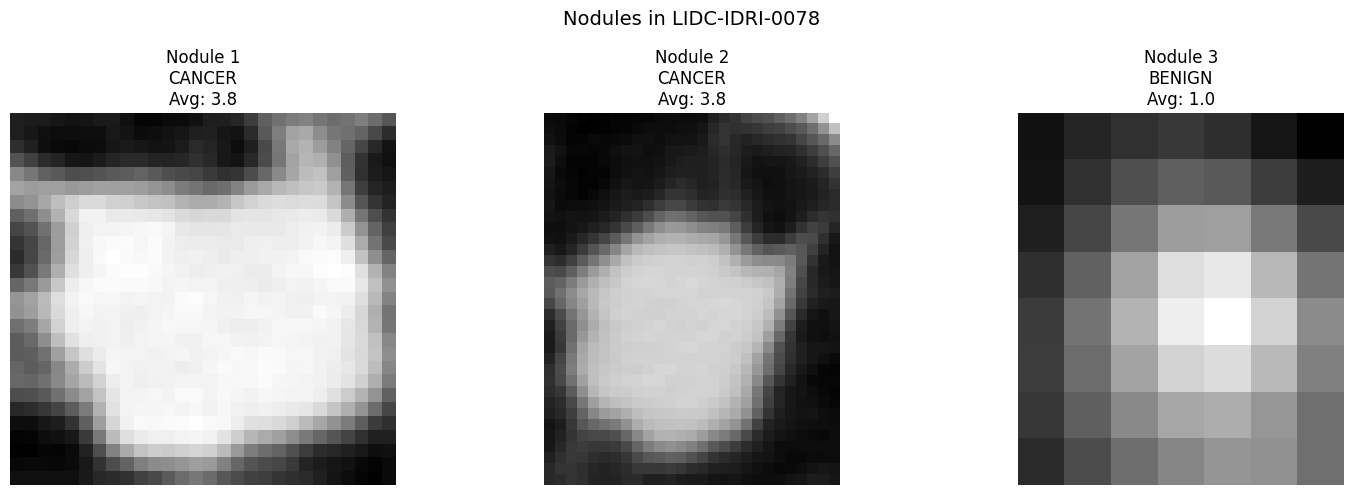

: 

In [ ]:
# Cell 2
# Visualise each nodule up close
target_nodules = 3

# If current scan has too few nodules, pick another scan with more nodules.
if len(nodules) < target_nodules:
    print(f"Current scan {scan.patient_id} has {len(nodules)} nodule(s). Searching for a richer example...")
    for candidate_scan in scans:
        candidate_nodules = candidate_scan.cluster_annotations()
        if len(candidate_nodules) >= target_nodules:
            scan = candidate_scan
            nodules = candidate_nodules
            volume = scan.to_volume()
            print(f"Using scan {scan.patient_id} with {len(nodules)} nodules.")
            break

if len(nodules) == 0:
    print("No nodules found for this scan.")
else:
    nodules_to_show = nodules[:target_nodules]
    fig, axes = plt.subplots(1, len(nodules_to_show), figsize=(5 * len(nodules_to_show), 5))
    axes = np.atleast_1d(axes)

    for i, nodule in enumerate(nodules_to_show):
        # Get malignancy label
        malignancy_scores = [ann.malignancy for ann in nodule]
        avg_malignancy = np.mean(malignancy_scores)
        label = 'CANCER' if avg_malignancy >= 3 else 'BENIGN'
        
        # Get the nodule's position in the scan
        ann = nodule[0]
        bbox = ann.bbox()
        
        # Get the center slice of the nodule
        center_slice = (bbox[2].start + bbox[2].stop) // 2
        
        # Crop the region around the nodule
        nodule_image = volume[
            bbox[0].start:bbox[0].stop,
            bbox[1].start:bbox[1].stop,
            center_slice
        ]
        
        # Show it
        axes[i].imshow(nodule_image, cmap='gray')
        axes[i].set_title(f'Nodule {i+1}\n{label}\nAvg: {avg_malignancy:.1f}')
        axes[i].axis('off')

    plt.suptitle(f'Nodules in {scan.patient_id}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [6]:
# Cell 3
# =============================================
# Count cancer vs benign across all patients
# =============================================

# We are counting nodules from all 1018 patients
# One patient can have multiple nodules
# Each nodule is counted separately

cancer_count = 0
benign_count = 0
total_nodules = 0

print("Analysing entire dataset...")
print("This may take a minute...\n")

for i, scan in enumerate(scans):
    try:
        nodules = scan.cluster_annotations()
        for nodule in nodules:
            malignancy_scores = [ann.malignancy for ann in nodule]
            avg = np.mean(malignancy_scores)
            if avg >= 3:
                cancer_count += 1
            else:
                benign_count += 1
            total_nodules += 1
    except:
        pass

    # Print progress every 100 scans
    if (i + 1) % 100 == 0:
        print(f"Processed {i+1}/1018 scans...")

# =============================================
# Final summary
# =============================================
print("\n" + "=" * 40)
print("DATASET SUMMARY")
print("=" * 40)
print(f"Total nodules:   {total_nodules}")
print(f"Cancer nodules:  {cancer_count}")
print(f"Benign nodules:  {benign_count}")
print(f"Cancer %:        {cancer_count/total_nodules*100:.1f}%")
print(f"Benign %:        {benign_count/total_nodules*100:.1f}%")
print("=" * 40)

#Simple example to make it clear
#Imagine just 3 patients:

#patient 001 - 1 cancer,1 benign
#patient 002 - 2 benign
#patient 003 - 2 cancer,1 benign
#Total nodules = 7
#Cancer nodules = 3 (42%)
#Benign nodules = 4 (58%)
#But only 2 out of 3 patients actually have cancer.
#like wise here we are considering about all the patients.

Analysing entire dataset...
This may take a minute...

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Processed 100/1018 scans...
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Processed 200/1018 scans...
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Processed 300/1018 scans...
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Processed 400/1018 sc

In [1]:
# Cell 4
import pylidc as pl
import os

# Tell pylidc where your data is
os.environ['LIDC_IDRI_PATH'] = r'C:\Users\User\Desktop\Lung Cancer Detection\data\raw\LIDC-IDRI'

# Check how many scans are available
scans = pl.query(pl.Scan).all()
print(f"Total scans found: {len(scans)}")

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\pylidc\__init__.py:27: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as _pr


Total scans found: 1018


In [2]:
# Cell 5
from pathlib import Path
import configparser
import pylidc.Scan as pl_scan

# Load the first scan
scan = scans[0]

# Print basic information about it
print(f"Patient ID:        {scan.patient_id}")
print(f"Slice thickness:   {scan.slice_thickness} mm")
print(f"Pixel spacing:     {scan.pixel_spacing} mm")
print(f"Number of slices:  {scan.slice_zvals.shape[0]}")

# Python 3.13 compatibility shim for pylidc using deprecated SafeConfigParser
if not hasattr(configparser, "SafeConfigParser"):
    configparser.SafeConfigParser = configparser.ConfigParser

# Point pylidc to this project's local LIDC-IDRI directory
candidate_paths = [
    Path.cwd() / "data" / "raw" / "LIDC-IDRI",
    Path.cwd().parent / "data" / "raw" / "LIDC-IDRI",
]
dicom_root = next((p for p in candidate_paths if p.exists()), None)
if dicom_root is None:
    raise FileNotFoundError("Could not find data/raw/LIDC-IDRI from current notebook location.")

pl_scan._get_dicom_file_path_from_config_file = lambda: str(dicom_root)

# Load the actual 3D volume as a numpy array
volume = scan.to_volume()
print(f"\nCT scan shape:     {volume.shape}")
print(f"Min HU value:      {volume.min()}")
print(f"Max HU value:      {volume.max()}")

Patient ID:        LIDC-IDRI-0078
Slice thickness:   3.0 mm
Pixel spacing:     0.65 mm
Number of slices:  87
Loading dicom files ... This may take a moment.

CT scan shape:     (512, 512, 87)
Min HU value:      -2048
Max HU value:      8155


In [3]:
# Cell 6
# TODO:import os
import numpy as np
import matplotlib.pyplot as plt
import pylidc as pl

print("All libraries imported successfully!") 


All libraries imported successfully!


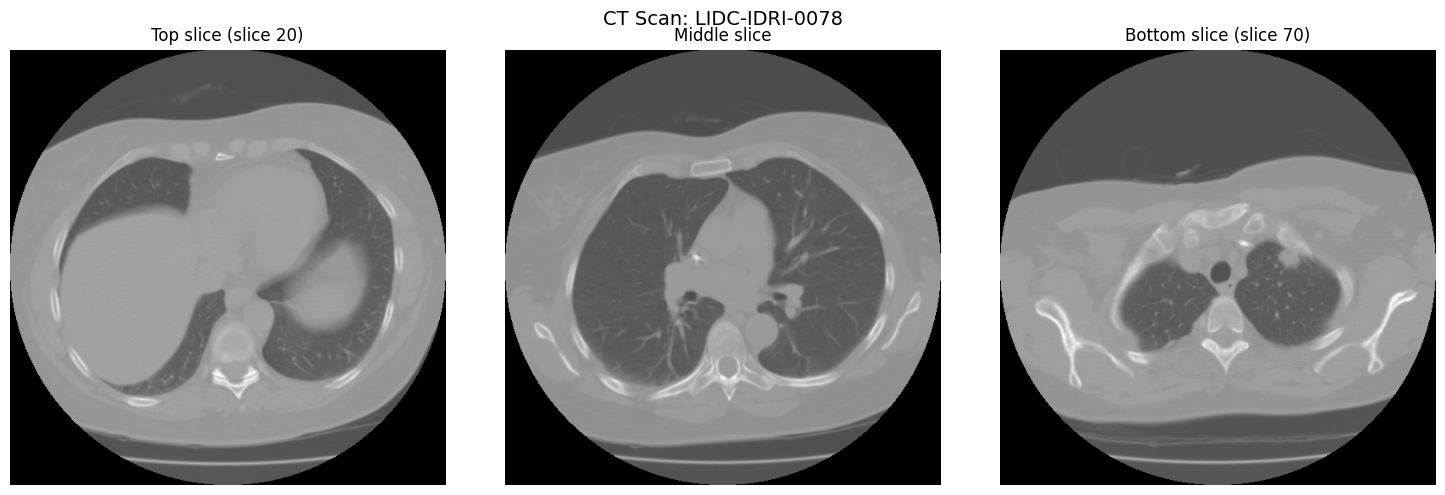

In [ ]:
# Cell 7
# Show 3 slices from the CT scan
# top, middle, and bottom of the chest

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Top slice
axes[0].imshow(volume[:, :, 20], cmap='gray')
axes[0].set_title('Top slice (slice 20)')
axes[0].axis('off')

# Middle slice
axes[1].imshow(volume[:, :, volume.shape[2]//2], cmap='gray')
axes[1].set_title('Middle slice')
axes[1].axis('off')

# Bottom slice
axes[2].imshow(volume[:, :, 70], cmap='gray')
axes[2].set_title('Bottom slice (slice 70)')
axes[2].axis('off')

plt.suptitle(f'CT Scan: {scan.patient_id}', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Cell 8
import numpy as np

# Compatibility shim for pylidc on NumPy 2.x
if not hasattr(np, "int"):
    np.int = int

# Get all nodules in this scan
nodules = scan.cluster_annotations()
print(f"Number of nodules found: {len(nodules)}")

# Look at each nodule
for i, nodule in enumerate(nodules):
    # Get malignancy ratings from all radiologists
    malignancy_scores = [ann.malignancy for ann in nodule]
    avg_malignancy = np.mean(malignancy_scores)
    label = 1 if avg_malignancy >= 3 else 0
    
    print(f"\nNodule {i+1}:")
    print(f"  Radiologist ratings: {malignancy_scores}")
    print(f"  Average malignancy:  {avg_malignancy:.1f}")
    print(f"  Label:               {'CANCER' if label == 1 else 'BENIGN'}")

Number of nodules found: 4

Nodule 1:
  Radiologist ratings: [3, 4, 5, 3]
  Average malignancy:  3.8
  Label:               CANCER

Nodule 2:
  Radiologist ratings: [3, 4, 5, 3]
  Average malignancy:  3.8
  Label:               CANCER

Nodule 3:
  Radiologist ratings: [1]
  Average malignancy:  1.0
  Label:               BENIGN

Nodule 4:
  Radiologist ratings: [4, 5, 5, 3]
  Average malignancy:  4.2
  Label:               CANCER
